In [1]:
import uproot
import numpy as np
import utils
from tqdm import tqdm
import importlib
import matplotlib.pyplot as plt
import drawing

In [2]:
# base_path = "/eos/user/l/ligerlac/cicada_data/skimmed-2025-07-09"
# base_path = "../data/skimmed-2025-07-09"
base_path = "../data/skimmed-2026-04-28"

branches = [
    "CICADA2024_CICADAScore",
    "CICADA2025_CICADAScore",
    "axol1tl_v3_AXOScore",
    "axol1tl_v4_AXOScore",
    "PV_npvs",
    "PV_npvsGood",
    "et",
    "is_pure"
]

process_list = [
    "GluGluHToGG",
    "HTo2LongLivedTo4b",
    "TT",
    "VBFHtoTauTau",
    "ZprimeToTauTau",
    "GluGluToTauTau",
    "SingleNeutrino",
    "VBFHto2B",
    "ZB",
    "ZZ",
]


def get_array(proc, var):
    file_name = f"{base_path}/{proc}.root:Events"
    with uproot.open(file_name) as events:
        # print all available branches
        # print(f"Available branches in {proc}: {events.keys()}")
        return events[var].array(library="np")


In [10]:
# load all variables from file
et_dict, is_pure_dict, npv_dict, l1_zb_dict, lumi_dict, cicada_score_dict, axo_score_dict = {}, {}, {}, {}, {}, {}, {}
for proc in ["ZB", "HTo2LongLivedTo4b", "GluGluHToGG", "VBFHto2B", "SUEP", "TT", "SingleNeutrino"]:
    print(f"Loading {proc}...")
    et_dict[proc] = get_array(proc, "et")
    is_pure_dict[proc] = get_array(proc, "is_pure")
    npv_dict[proc] = get_array(proc, "PV_npvsGood")
    l1_zb_dict[proc] = get_array(proc, "L1_ZeroBias")
    lumi_dict[proc] = get_array(proc, "luminosityBlock")
    cicada_score_dict[proc] = get_array(proc, "CICADA2024_CICADAScore")
    axo_score_dict[proc] = get_array(proc, "axol1tl_v4_AXOScore")

# npv_mask = npv_dict["ZB"] > 10
npv_mask = (npv_dict["ZB"] > 10) * (l1_zb_dict["ZB"] == True)  # only consider events with more than 10 primary vertices and L1_ZeroBias==True
# l1_mask = l1_zb_dict["ZB"] == True

# et_dict["ZB-masked"] = et_dict["ZB"][npv_mask]
# npv_dict["ZB-masked"] = npv_dict["ZB"][npv_mask]
# is_pure_dict["ZB-masked"] = is_pure_dict["ZB"][npv_mask]

# et_dict["ZB"] = et_dict["ZB"][l1_mask]
# npv_dict["ZB"] = npv_dict["ZB"][l1_mask]
# is_pure_dict["ZB"] = is_pure_dict["ZB"][l1_mask]

et_dict["ZB"] = et_dict["ZB"][npv_mask]
npv_dict["ZB"] = npv_dict["ZB"][npv_mask]
is_pure_dict["ZB"] = is_pure_dict["ZB"][npv_mask]
cicada_score_dict["ZB"] = cicada_score_dict["ZB"][npv_mask]
axo_score_dict["ZB"] = axo_score_dict["ZB"][npv_mask]

# l1_zb_mask = l1_zb_dict["ZB"]
# et_dict["ZB-l1zb-masked"] = et_dict["ZB"][l1_zb_mask]
# npv_dict["ZB-l1zb-masked"] = npv_dict["ZB"][l1_zb_mask]
# is_pure_dict["ZB-l1zb-masked"] = is_pure_dict["ZB"][l1_zb_mask]



Loading ZB...
Loading HTo2LongLivedTo4b...
Loading GluGluHToGG...
Loading VBFHto2B...
Loading SUEP...
Loading TT...
Loading SingleNeutrino...


In [4]:
# for proc in ["ZB", "HTo2LongLivedTo4b", "GluGluHToGG", "VBFHto2B", "SUEP", "TT", "SingleNeutrino"]:
#     print(f"{l1_zb_dict[proc].shape=}, {np.sum(l1_zb_dict[proc])=}, {np.sum(l1_zb_dict[proc])/len(l1_zb_dict[proc])=}")
# #     print(f"{proc}: {len(et_dict[proc])} events, {np.sum(is_pure_dict[proc])} pure events, {np.sum(is_pure_dict[proc])/len(is_pure_dict[proc])} purity")
# # print(f"{l1_zb_mask.shape=}, {np.sum(l1_zb_mask)=}, {np.sum(l1_zb_mask)/len(l1_zb_mask)=}")


In [6]:
# import mplhep as hep
# plt.figure(figsize=(9, 6))
# hep.hist(npv_dict["ZB"], bins=range(70), alpha=0.5, label="ZB", density=True)
# hep.hist(npv_dict["ZB"][l1_zb_dict["ZB"]==True], bins=range(70), alpha=0.5, label="ZB, L1_ZeroBias==True", density=True)
# hep.hist(npv_dict["ZB"][lumi_dict["ZB"]>100], bins=range(70), alpha=0.5, label="ZB, lumi > 100", density=True)
# hep.hist(npv_dict["ZB"][(lumi_dict["ZB"]>100) * (l1_zb_dict["ZB"]==True)], bins=range(70), alpha=0.5, label="ZB, L1_ZeroBias==True & lumi > 100", density=True)
# plt.xlabel("nPV")

# plt.legend()

In [7]:
# ls = list(range(2000))
# npvs, npvs_l1_zb = [], []
# for l in ls:
#     m = (lumi_dict["ZB"]==l)
#     m_l1_zb = l1_zb_dict["ZB"][m]
#     npv_ = npv_dict["ZB"][m]
#     npvs.append(npv_.mean())
#     npvs_l1_zb.append(npv_[m_l1_zb].mean())


In [8]:
# plt.figure(figsize=(8, 6))
# plt.plot(ls, npvs, label="ZB (inclusive)")
# plt.plot(ls, npvs_l1_zb, label="ZB (L1_ZeroBias==True)")
# plt.legend()
# plt.xlabel("Lumi Block Number")
# plt.ylabel("Average nPV")

In [11]:
# npv reweighting study
npv_arr = range(100)
weights = {}
# npv_data = npv_dict["ZB-masked"]
npv_data = npv_dict["ZB"]

for proc in ["HTo2LongLivedTo4b", "GluGluHToGG", "VBFHto2B", "SUEP", "TT", "SingleNeutrino"]:
    npv_mc = npv_dict[proc]
    weights[proc] = np.zeros_like(npv_mc, dtype=float)
    for npv_ in npv_arr:
        idx_data = npv_data == npv_
        idx_mc = npv_mc == npv_
        w = np.sum(idx_data) / np.sum(idx_mc)
        weights[proc][idx_mc] = w
    weights[proc] = np.array(weights[proc])
    weights[proc][~np.isfinite(weights[proc])] = 0.0


/var/folders/c0/9f43s3c12sn447zr9wy8pp3c0000gn/T/ipykernel_1685/2850570722.py:13: RuntimeWarning: invalid value encountered in scalar divide
  w = np.sum(idx_data) / np.sum(idx_mc)
/var/folders/c0/9f43s3c12sn447zr9wy8pp3c0000gn/T/ipykernel_1685/2850570722.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  w = np.sum(idx_data) / np.sum(idx_mc)


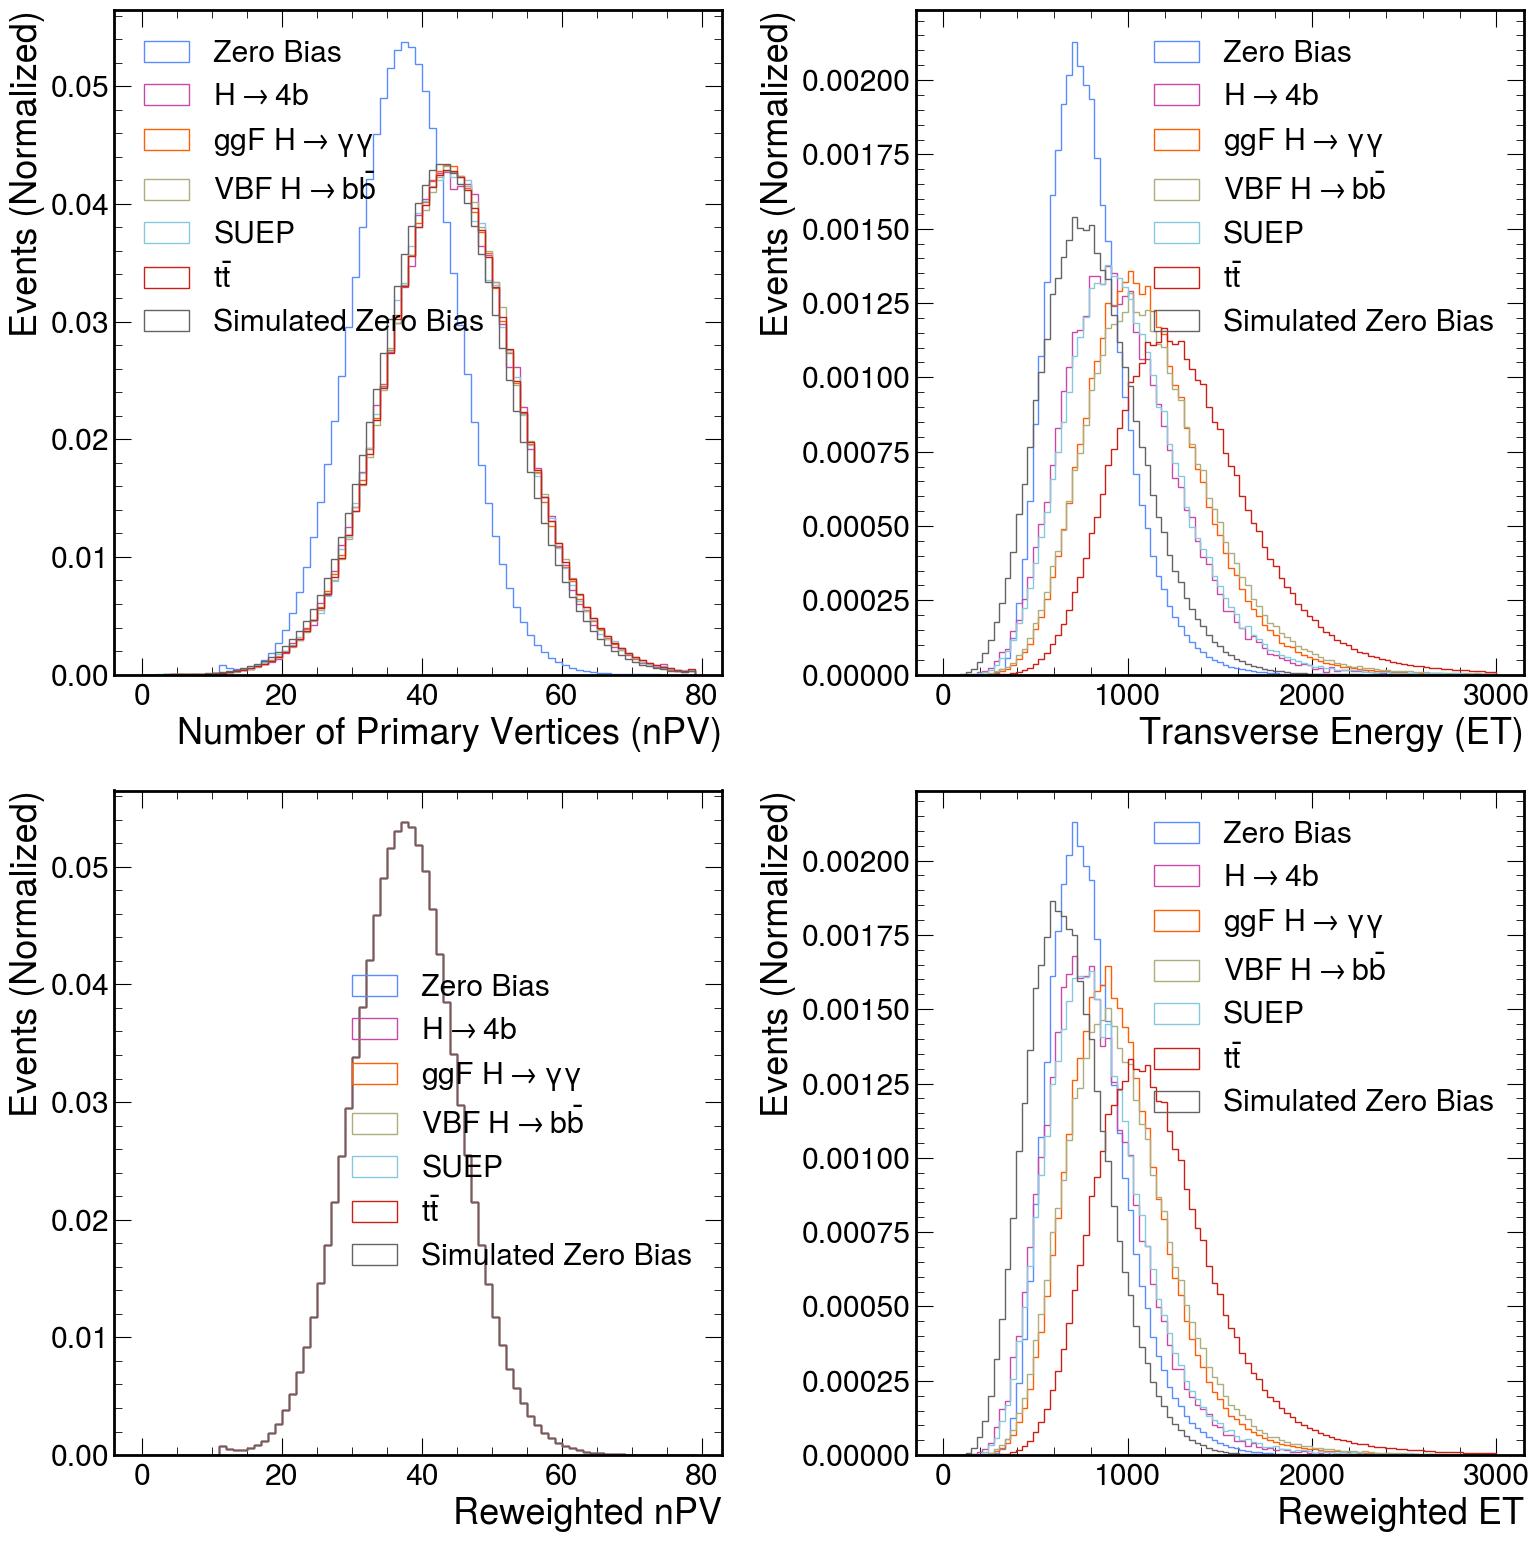

In [13]:
import importlib
import drawing
importlib.reload(drawing)
draw = drawing.Draw(interactive=True)

draw.make_npv_reweighting_plot(
    npv_dict=npv_dict,
    et_dict=et_dict,
    weight_dict=weights,
)

In [ ]:
# # the order plays a role here!
# proc_list = [
#     "ZB",
#     "SingleNeutrino",
#     "HTo2LongLivedTo4b",
#     "GluGluHToGG",
#     "VBFHto2B",
#     "SUEP",
#     "TT",
# ]

# cicada_score_dict = {
#     proc: get_array(proc, "CICADA2024_CICADAScore") for proc in proc_list
# }
# cicada_score_dict["ZB-masked"] = cicada_score_dict["ZB"][npv_mask]
# cicada_score_dict["ZB"] = cicada_score_dict["ZB"][l1_mask]

# axo_score_dict = {
#     proc: get_array(proc, "axol1tl_v4_AXOScore") for proc in proc_list
# }
# axo_score_dict["ZB-masked"] = axo_score_dict["ZB"][npv_mask]
# axo_score_dict["ZB"] = axo_score_dict["ZB"][l1_mask]

Left legend keyzs: ['ZB', 'SingleNeutrino'], Right legend keys: ['HTo2LongLivedTo4b', 'GluGluHToGG', 'VBFHto2B', 'SUEP', 'TT']


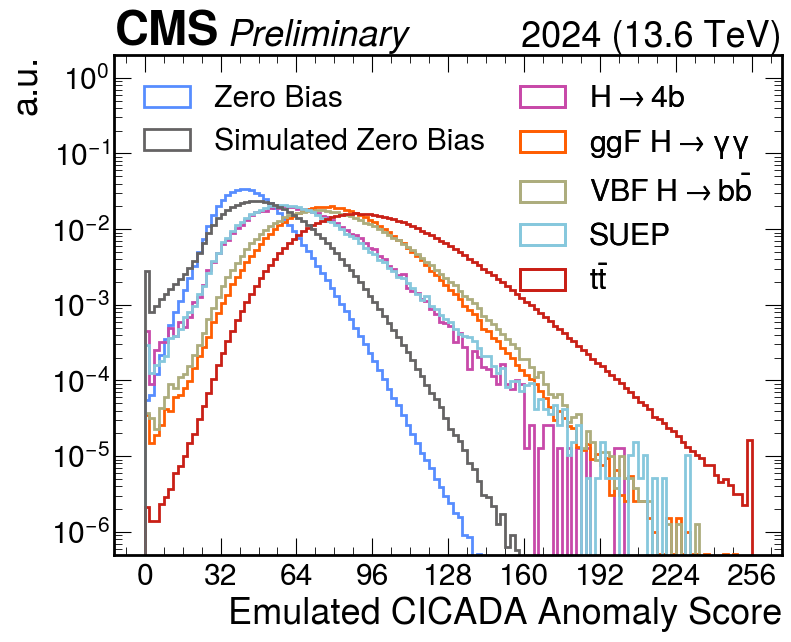

Left legend keyzs: ['ZB', 'SingleNeutrino'], Right legend keys: ['HTo2LongLivedTo4b', 'GluGluHToGG', 'VBFHto2B', 'SUEP', 'TT']


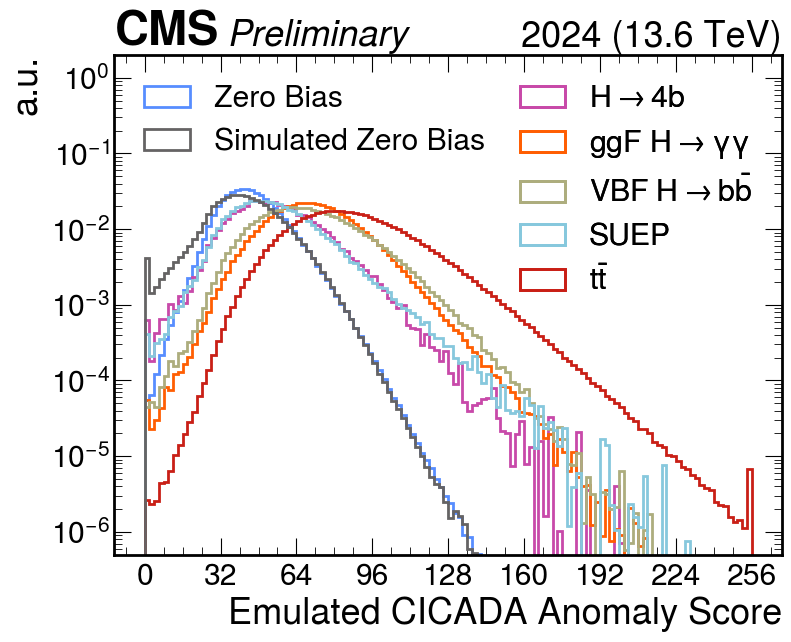

Left legend keyzs: ['ZB', 'SingleNeutrino'], Right legend keys: ['HTo2LongLivedTo4b', 'GluGluHToGG', 'VBFHto2B', 'SUEP', 'TT']


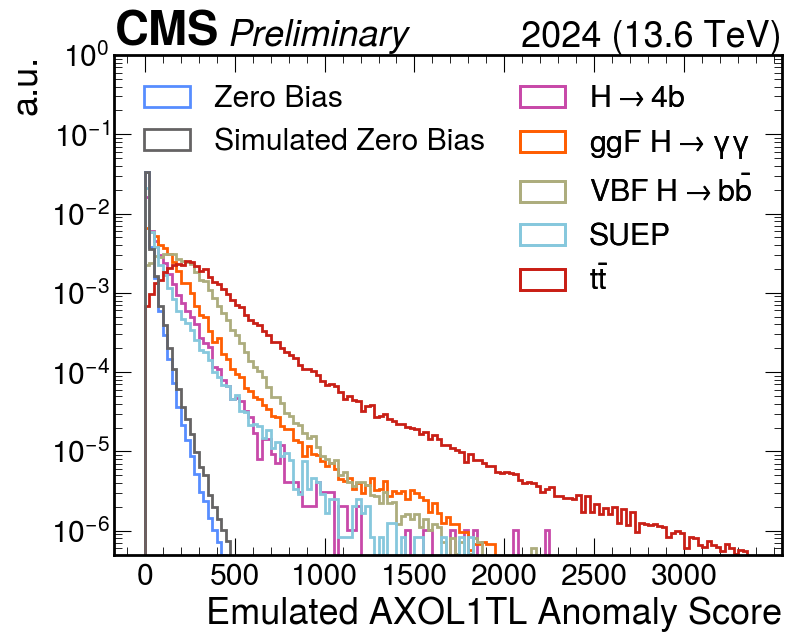

Left legend keyzs: ['ZB', 'SingleNeutrino'], Right legend keys: ['HTo2LongLivedTo4b', 'GluGluHToGG', 'VBFHto2B', 'SUEP', 'TT']


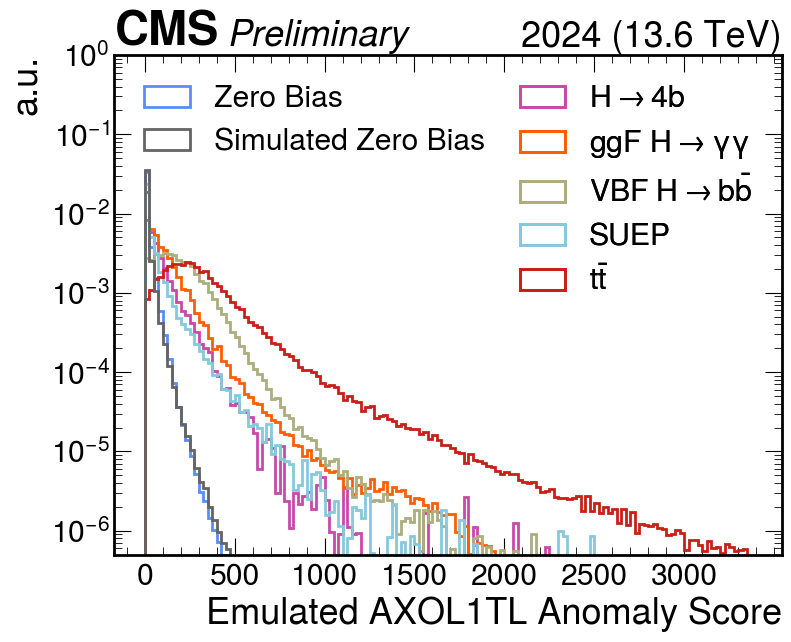

In [21]:
importlib.reload(drawing)
draw = drawing.Draw(interactive=True, output_format="pdf")


draw.plot_anomaly_score_distribution(
    cicada_score_dict.values(),
    labels=list(cicada_score_dict.keys()),
    name="as-dist-cicada",
    xlabel="Emulated CICADA Anomaly Score",
    bins=range(0, 258, 2),
    xticks=range(0, 258, 32),
    # left_legend_col=(0, -1, 1),
    left_legend_col=(0, -1),
    # y_max=10,
    y_max=2,
    figsize=(8.5, 7),
)

draw.plot_anomaly_score_distribution(
    cicada_score_dict.values(),
    labels=list(cicada_score_dict.keys()),
    name="as-dist-cicada-rw",
    xlabel="Emulated CICADA Anomaly Score",
    bins=range(0, 258, 2),
    xticks=range(0, 258, 32),
    # left_legend_col=(0, -1, 1),
    left_legend_col=(0, -1),
    weights=weights,
    # y_max=10,
    y_max=2,
    figsize=(8.5, 7),
)

draw.plot_anomaly_score_distribution(
    axo_score_dict.values(),
    labels=list(axo_score_dict.keys()),
    name="as-dist-axo",
    xlabel="Emulated AXOL1TL Anomaly Score",
    bins=range(0, 3400, 25),
    xticks=range(0, 3400, 500),
    # left_legend_col=(0, -1, 1),
    left_legend_col=(0, -1),
    # y_max=2,
    y_max=1,
    figsize=(8.5, 7),
)

draw.plot_anomaly_score_distribution(
    axo_score_dict.values(),
    labels=list(axo_score_dict.keys()),
    name="as-dist-axo-rw",
    xlabel="Emulated AXOL1TL Anomaly Score",
    bins=range(0, 3400, 25),
    xticks=range(0, 3400, 500),
    # left_legend_col=(0, -1, 1),
    left_legend_col=(0, -1),
    # y_max=2,
    y_max=1,
    weights=weights,
    figsize=(8.5, 7),
)

In [22]:
importlib.reload(utils)

proc_list = [
    "ZB",
    "SingleNeutrino",
    "HTo2LongLivedTo4b",
    "GluGluHToGG",
    "VBFHto2B",
    "SUEP",
    "TT",
]

bg_labels = ["ZB", "ZB-masked", "SingleNeutrino"]
sig_labels = [l for l in proc_list if l not in bg_labels]

# roc_dict_cicada = utils.get_roc_dict(cicada_score_dict, "ZB-masked", sig_labels)
roc_dict_cicada = utils.get_roc_dict(cicada_score_dict, "ZB", sig_labels)
roc_dict_cicada_baseline = utils.get_roc_dict(cicada_score_dict, "SingleNeutrino", sig_labels)

# roc_dict_axo = utils.get_roc_dict(axo_score_dict, "ZB-masked", sig_labels)
roc_dict_axo = utils.get_roc_dict(axo_score_dict, "ZB", sig_labels)
roc_dict_axo_baseline = utils.get_roc_dict(axo_score_dict, "SingleNeutrino", sig_labels)

In [24]:
# roc_dict_cicada_rw = utils.get_roc_dict(cicada_score_dict, "ZB-masked", sig_labels, weight_dict=weights)
roc_dict_cicada_rw = utils.get_roc_dict(cicada_score_dict, "ZB", sig_labels, weight_dict=weights)
roc_dict_cicada_baseline_rw = utils.get_roc_dict(cicada_score_dict, "SingleNeutrino", sig_labels, weight_dict=weights)

# roc_dict_axo_rw = utils.get_roc_dict(axo_score_dict, "ZB-masked", sig_labels, weight_dict=weights)
roc_dict_axo_rw = utils.get_roc_dict(axo_score_dict, "ZB", sig_labels, weight_dict=weights)
roc_dict_axo_baseline_rw = utils.get_roc_dict(axo_score_dict, "SingleNeutrino", sig_labels, weight_dict=weights)

In [26]:
cicada_score_dict_pure = {proc: score[is_pure_dict[proc]] for proc, score in cicada_score_dict.items()}
axo_score_dict_pure = {proc: score[is_pure_dict[proc]] for proc, score in axo_score_dict.items()}
weights_pure = {proc: w[is_pure_dict[proc]] for proc, w in weights.items()}

# roc_dict_cicada_pure_rw = utils.get_roc_dict(cicada_score_dict_pure, "ZB-masked", sig_labels, weight_dict=weights_pure)
roc_dict_cicada_pure_rw = utils.get_roc_dict(cicada_score_dict_pure, "ZB", sig_labels, weight_dict=weights_pure)
roc_dict_cicada_baseline_pure_rw = utils.get_roc_dict(cicada_score_dict_pure, "SingleNeutrino", sig_labels, weight_dict=weights_pure)

# roc_dict_axo_pure_rw = utils.get_roc_dict(axo_score_dict_pure, "ZB-masked", sig_labels, weight_dict=weights_pure)
roc_dict_axo_pure_rw = utils.get_roc_dict(axo_score_dict_pure, "ZB", sig_labels, weight_dict=weights_pure)
roc_dict_axo_baseline_pure_rw = utils.get_roc_dict(axo_score_dict_pure, "SingleNeutrino", sig_labels, weight_dict=weights_pure)


In [64]:
# calculate the inclusive L1 working points
any_l1_dict = {k: ~ip for k, ip in is_pure_dict.items()}

# should be 110kHz, but in reality it is 88.58kHz
fpr = any_l1_dict["ZB"].sum() / len(any_l1_dict["ZB"])

l1_wps, l1_wps_rw = {}, {}

for proc, arr in any_l1_dict.items():
    if proc == "ZB" or proc == "SingleNeutrino":
        continue
    eff = arr.sum() / len(arr)
    eff_rw = np.sum(weights[proc][arr]) / np.sum(weights[proc])
    l1_wps[proc] = (fpr, eff)
    l1_wps_rw[proc] = (fpr, eff_rw)


In [ ]:

print("any_l1_dict")
for proc, arr in any_l1_dict.items():
    print(f"{proc=}, {arr.shape=}, {arr.sum()=}, {arr.sum()/len(arr)=}")

print("cicada_score_dict")
for proc, arr in cicada_score_dict.items():
    print(f"{proc=}, {arr.shape=}, {arr.sum()=}, {arr.sum()/len(arr)=}")


In [44]:
print("roc_dict_cicada")
for proc, arr in roc_dict_cicada.items():
    print(f"{proc=}, {len(arr)=}, {arr[0].shape=}, {arr[1].shape=}")

print("roc_dict_l1")
for proc, arr in roc_dict_l1.items():
    print(f"{proc=}, {len(arr)=}, {arr[0].shape=}, {arr[1].shape=}")

# print(roc_dict_cicada)
# print(roc_dict_l1)

roc_dict_cicada
proc='HTo2LongLivedTo4b', len(arr)=2, arr[0].shape=(30277,), arr[1].shape=(30277,)
proc='GluGluHToGG', len(arr)=2, arr[0].shape=(37504,), arr[1].shape=(37504,)
proc='VBFHto2B', len(arr)=2, arr[0].shape=(36029,), arr[1].shape=(36029,)
proc='SUEP', len(arr)=2, arr[0].shape=(31226,), arr[1].shape=(31226,)
proc='TT', len(arr)=2, arr[0].shape=(55684,), arr[1].shape=(55684,)
roc_dict_l1
proc='HTo2LongLivedTo4b', len(arr)=2, arr[0].shape=(3,), arr[1].shape=(3,)
proc='GluGluHToGG', len(arr)=2, arr[0].shape=(3,), arr[1].shape=(3,)
proc='VBFHto2B', len(arr)=2, arr[0].shape=(3,), arr[1].shape=(3,)
proc='SUEP', len(arr)=2, arr[0].shape=(3,), arr[1].shape=(3,)
proc='TT', len(arr)=2, arr[0].shape=(3,), arr[1].shape=(3,)


Working point VL at rate 1.6 kHz with TPR 0.18
Working point  at rate 1.1 kHz with TPR 0.15
Working point M at rate 0.62 kHz with TPR 0.12
Working point  at rate 0.37 kHz with TPR 0.10
Working point VT at rate 0.25 kHz with TPR 0.08


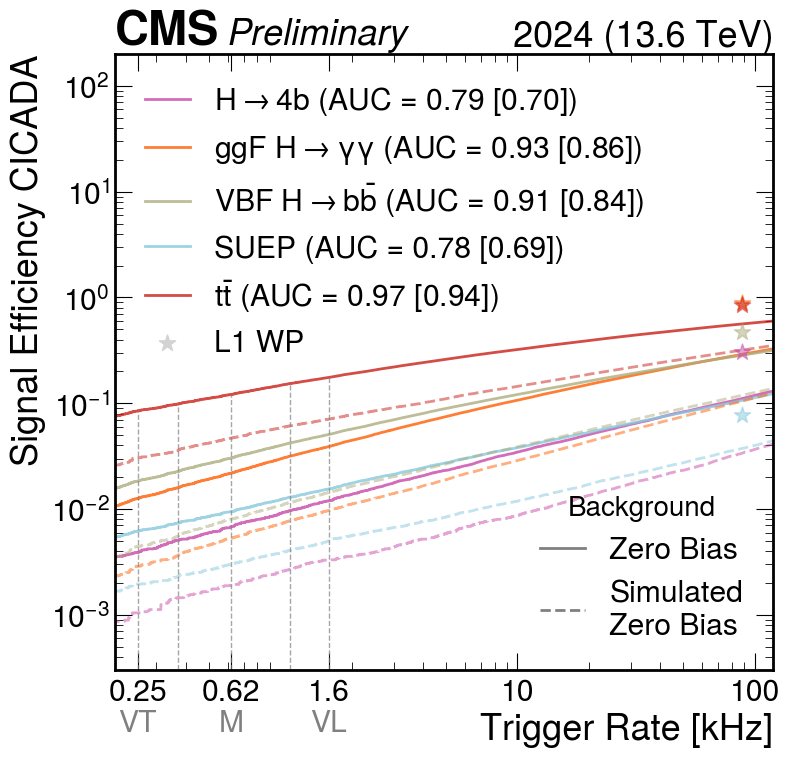

Working point VL at rate 1.6 kHz with TPR 0.10
Working point  at rate 1.1 kHz with TPR 0.09
Working point M at rate 0.62 kHz with TPR 0.07
Working point  at rate 0.37 kHz with TPR 0.05
Working point VT at rate 0.25 kHz with TPR 0.05


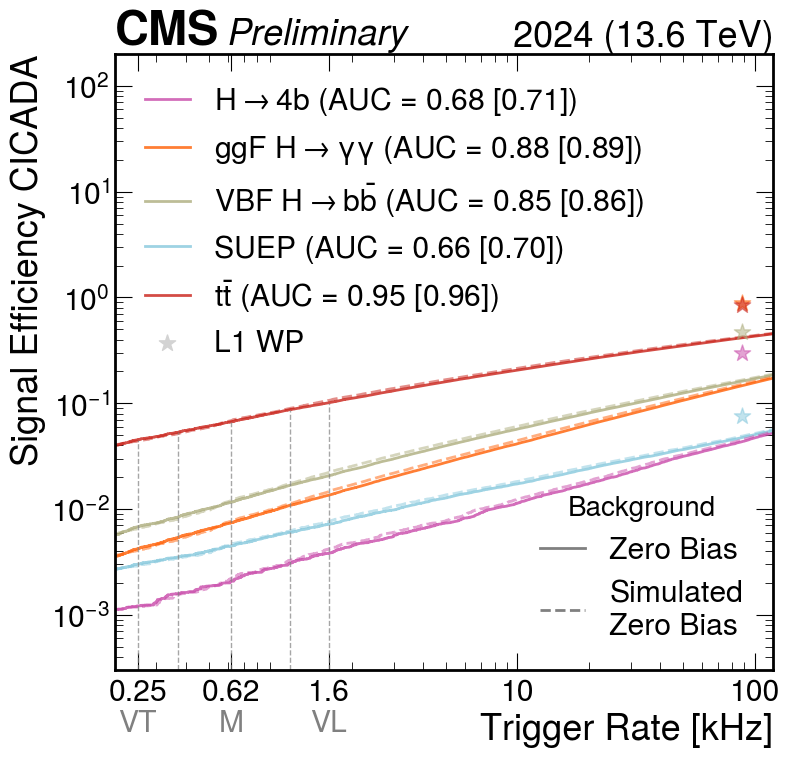

Working point VL at rate 3.8 kHz with TPR 0.35
Working point  at rate 2.2 kHz with TPR 0.29
Working point M at rate 1.5 kHz with TPR 0.25
Working point  at rate 1.1 kHz with TPR 0.22
Working point VT at rate 0.45 kHz with TPR 0.15


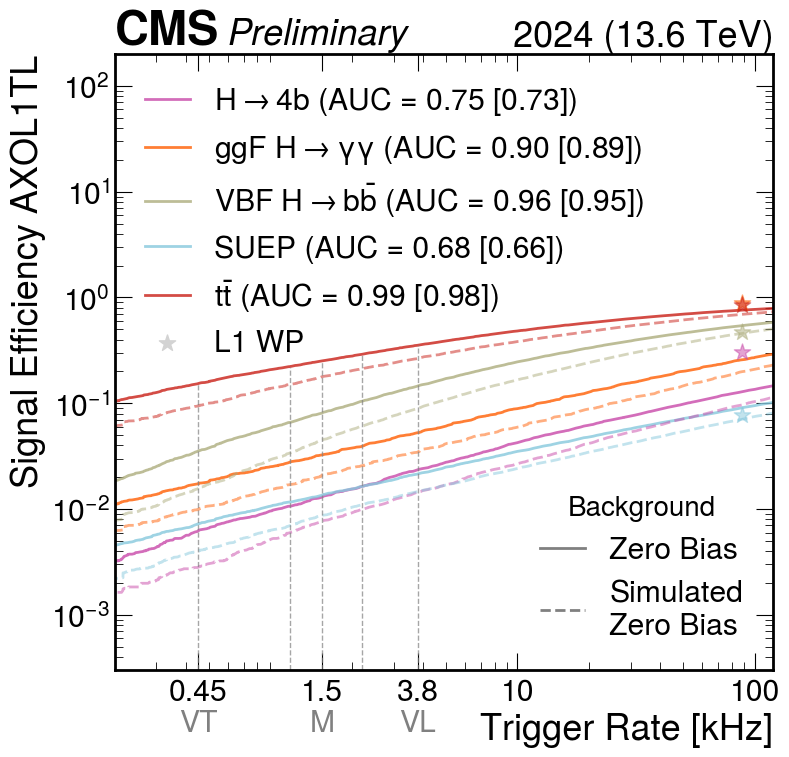

Working point VL at rate 3.8 kHz with TPR 0.34
Working point  at rate 2.2 kHz with TPR 0.28
Working point M at rate 1.5 kHz with TPR 0.24
Working point  at rate 1.1 kHz with TPR 0.21
Working point VT at rate 0.45 kHz with TPR 0.15


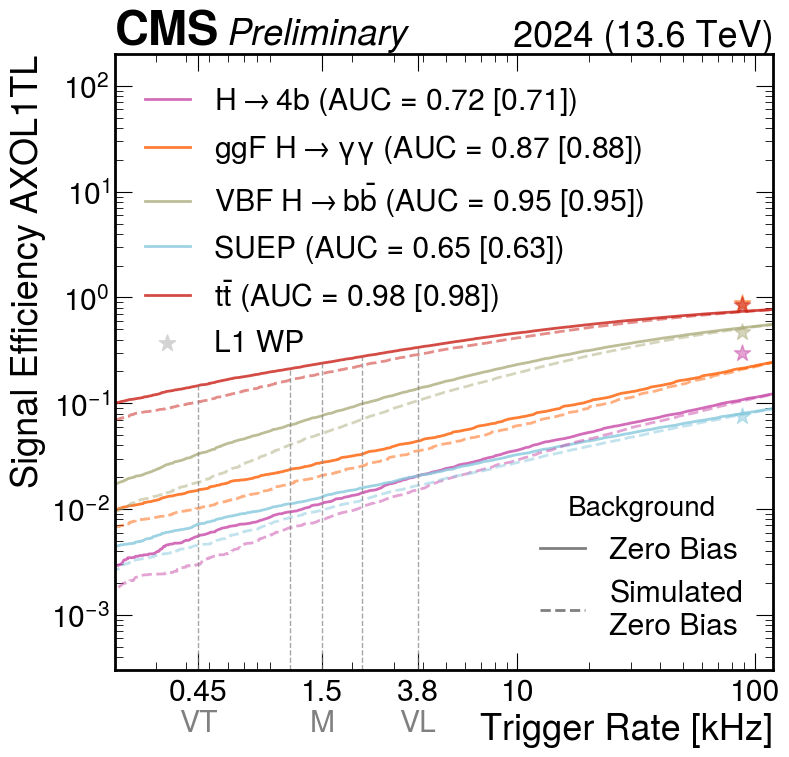

Working point VL at rate 1.6 kHz with TPR 0.01
Working point  at rate 1.1 kHz with TPR 0.01
Working point M at rate 0.62 kHz with TPR 0.00
Working point  at rate 0.37 kHz with TPR 0.00
Working point VT at rate 0.25 kHz with TPR 0.00


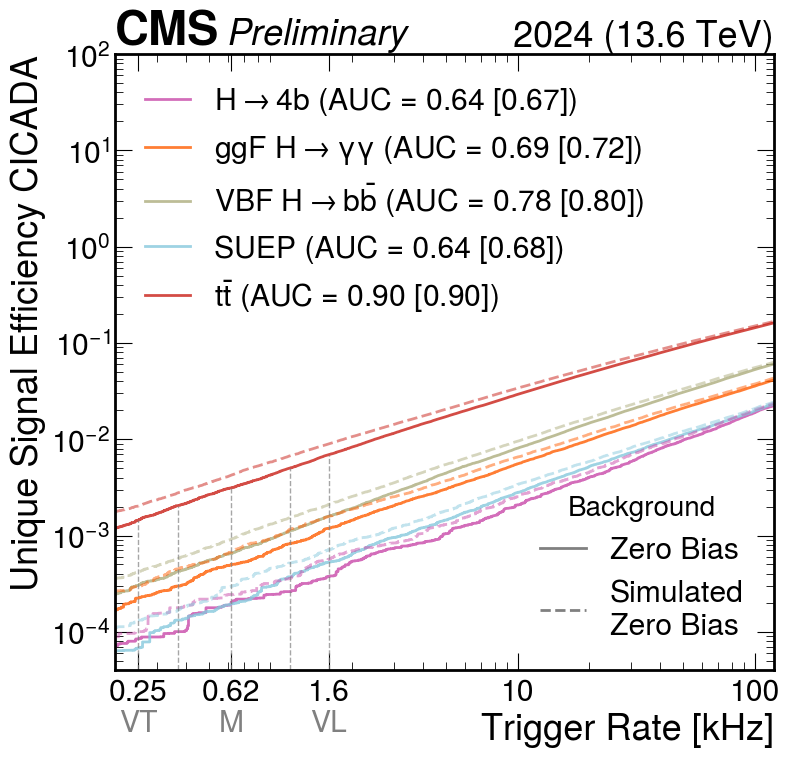

Working point VL at rate 3.8 kHz with TPR 0.13
Working point  at rate 2.2 kHz with TPR 0.09
Working point M at rate 1.5 kHz with TPR 0.07
Working point  at rate 1.1 kHz with TPR 0.05
Working point VT at rate 0.45 kHz with TPR 0.03


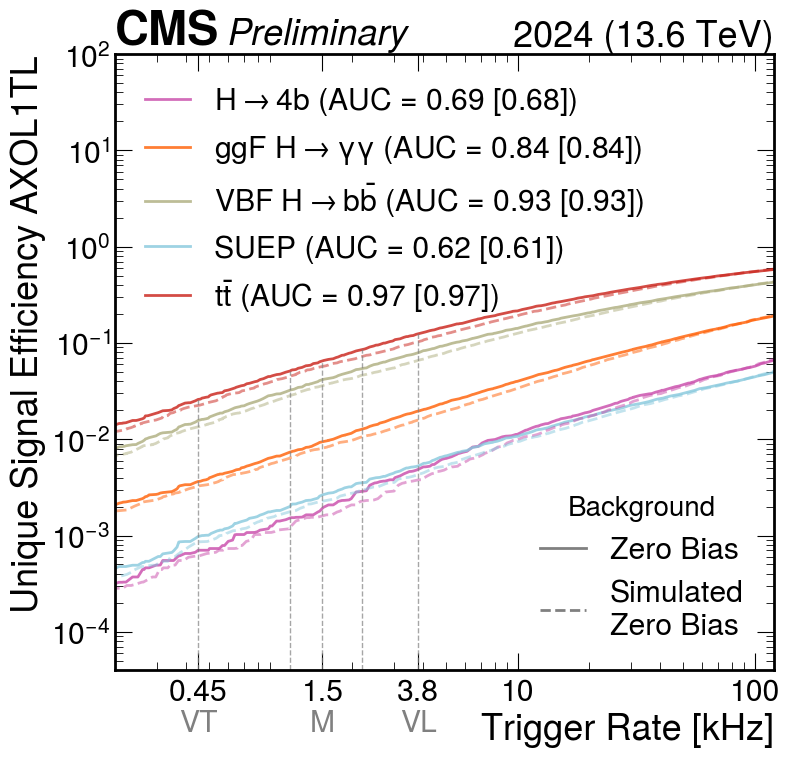

In [82]:
importlib.reload(drawing)
draw = drawing.Draw(interactive=True, output_format="pdf")


draw.plot_roc_curves(
    roc_dict_cicada,
    roc_dict_alt=roc_dict_cicada_baseline,
    baseline_points=l1_wps,
    alt_legend=("Background", ("Zero Bias", "Simulated\nZero Bias")),
    yrange=(0.0003, 200),
    xrange=(0.2, 120),
    working_points=((1.6, "VL"), (1.1, ""), (0.62, "M"), (0.37, ""), (0.25, "VT")),
    # working_points=((0.62, "Medium WP"),),
    ylabel="Signal Efficiency CICADA",
    figsize=(8.5, 8),
    name="roc-cicada",
)

draw.plot_roc_curves(
    roc_dict_cicada_rw,
    roc_dict_alt=roc_dict_cicada_baseline_rw,
    baseline_points=l1_wps_rw,
    alt_legend=("Background", ("Zero Bias", "Simulated\nZero Bias")),
    yrange=(0.0003, 200),
    # yrange=(0.0002, 20),
    xrange=(0.2, 120),
    working_points=((1.6, "VL"), (1.1, ""), (0.62, "M"), (0.37, ""), (0.25, "VT")),
    # working_points=((0.62, "Medium WP"),),
    ylabel="Signal Efficiency CICADA",
    figsize=(8.5, 8),
    name="roc-cicada-rw",
)

draw.plot_roc_curves(
    roc_dict_axo,
    roc_dict_alt=roc_dict_axo_baseline,
    baseline_points=l1_wps,
    alt_legend=("Background", ("Zero Bias", "Simulated\nZero Bias")),
    yrange=(0.0003, 200),
    xrange=(0.2, 120),
    working_points=((3.8, "VL"), (2.2, ""), (1.5, "M"), (1.1, ""), (0.45, "VT")),
    # working_points=((1.5, "Medium WP"),),
    ylabel="Signal Efficiency AXOL1TL",
    figsize=(8.5, 8),
    name="roc-axo",
)

draw.plot_roc_curves(
    roc_dict_axo_rw,
    roc_dict_alt=roc_dict_axo_baseline_rw,
    baseline_points=l1_wps_rw,
    alt_legend=("Background", ("Zero Bias", "Simulated\nZero Bias")),
    yrange=(0.0003, 200),
    xrange=(0.2, 120),
    working_points=((3.8, "VL"), (2.2, ""), (1.5, "M"), (1.1, ""), (0.45, "VT")),
    # working_points=((1.5, "Medium WP"),),
    ylabel="Signal Efficiency AXOL1TL",
    figsize=(8.5, 8),
    name="roc-axo-rw",
)

draw.plot_roc_curves(
    roc_dict_cicada_pure_rw,
    roc_dict_alt=roc_dict_cicada_baseline_pure_rw,
    alt_legend=("Background", ("Zero Bias", "Simulated\nZero Bias")),
    yrange=(0.00004, 100),
    # yrange=(0.0002, 20),
    xrange=(0.2, 120),
    working_points=((1.6, "VL"), (1.1, ""), (0.62, "M"), (0.37, ""), (0.25, "VT")),
    # working_points=((0.62, "Medium WP"),),
    ylabel="Unique Signal Efficiency CICADA",
    figsize=(8.5, 8),
    name="roc-cicada-pure-rw",
)

draw.plot_roc_curves(
    roc_dict_axo_pure_rw,
    roc_dict_alt=roc_dict_axo_baseline_pure_rw,
    alt_legend=("Background", ("Zero Bias", "Simulated\nZero Bias")),
    yrange=(0.00004, 100),
    xrange=(0.2, 120),
    working_points=((3.8, "VL"), (2.2, ""), (1.5, "M"), (1.1, ""), (0.45, "VT")),
    # working_points=((1.5, "Medium WP"),),
    ylabel="Unique Signal Efficiency AXOL1TL",
    figsize=(8.5, 8),
    name="roc-axo-pure-rw",
)

/var/folders/c0/9f43s3c12sn447zr9wy8pp3c0000gn/T/ipykernel_26988/1521469412.py:30: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax1.plot(rate, pure_rate, 'g-', color="#c91f16", label="CICADA")
/var/folders/c0/9f43s3c12sn447zr9wy8pp3c0000gn/T/ipykernel_26988/1521469412.py:31: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  ax2.plot(rate, pure_fraction, 'b-', color="#c91f16", linestyle=(0, (5, 10)))
/var/folders/c0/9f43s3c12sn447zr9wy8pp3c0000gn/T/ipykernel_26988/1521469412.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax2.plot(rate, pure_fraction, 'b-', color="#c91f16", linestyle=(0, (5, 10)))
/var/folders/c0/9f43s3c12sn447zr9wy8pp3c000

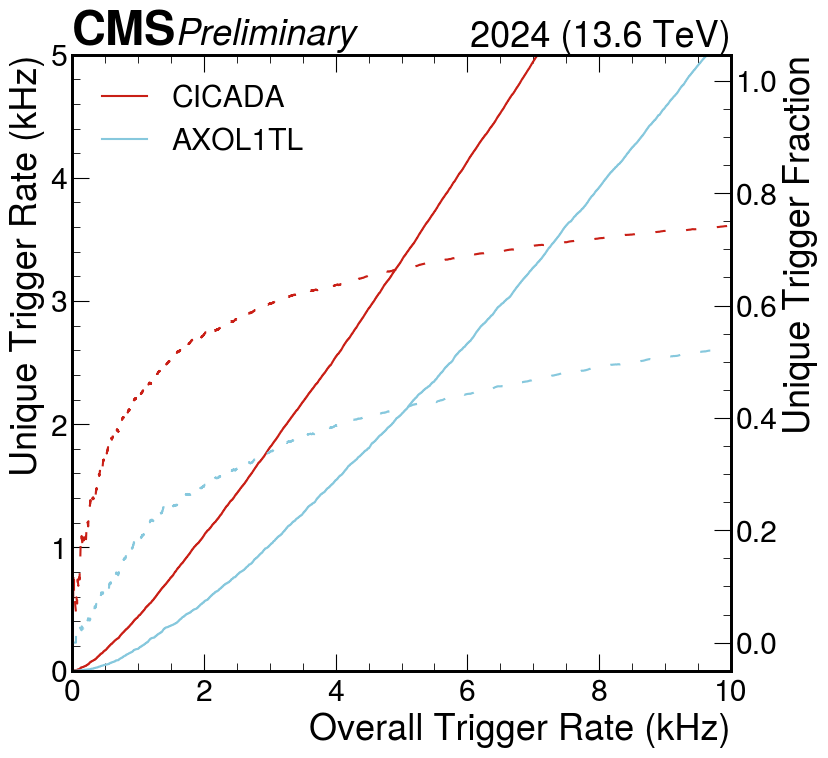

In [ ]:
# plot pure rate vs overall rate
# sort all scores in descending order
# apply same sorting to is_pure
# simply use len (arange) for rate estimate (each additional event adds to the rate)
# use cumsum to on is_pure get pure fraction as function of score
# use two y-axis (left for pure rate, right for pure fraction)
import matplotlib.pyplot as plt
import mplhep as hep


score_cic = cicada_score_dict["ZB-masked"]
score_axo = axo_score_dict["ZB-masked"]
is_pure = is_pure_dict["ZB-masked"]

N = len(is_pure)

idx = np.argsort(score_cic)[::-1]
score_sorted = score_cic[idx]
is_pure_sorted = is_pure[idx]

cumsum = np.cumsum(is_pure_sorted)
pure_fraction = cumsum / (np.arange(len(cumsum)) + 1)

rate = (np.arange(len(cumsum)) + 1) / N * 28610
pure_rate = np.cumsum(is_pure_sorted) / N * 28610

fig, ax1 = plt.subplots(figsize=(8.5, 8))

ax2 = ax1.twinx()
ax1.plot(rate, pure_rate, 'g-', color="#c91f16", label="CICADA")
ax2.plot(rate, pure_fraction, 'b-', color="#c91f16", linestyle=(0, (5, 10)))

idx = np.argsort(score_axo)[::-1]
score_sorted = score_axo[idx]
is_pure_sorted = is_pure[idx]

cumsum = np.cumsum(is_pure_sorted)
pure_fraction = cumsum / (np.arange(len(cumsum)) + 1)

rate = (np.arange(len(cumsum)) + 1) / N * 28610
pure_rate = np.cumsum(is_pure_sorted) / N * 28610

ax1.plot(rate, pure_rate, 'g-', color="#86c8dd", label="AXOL1TL")
ax2.plot(rate, pure_fraction, 'b-', color="#86c8dd", linestyle=(0, (5, 10)))

ax1.set_xlabel("Overall Trigger Rate (kHz)")
ax1.set_ylabel("Unique Trigger Rate (kHz)")
ax2.set_ylabel("Unique Trigger Fraction")
# set x range to be the same as the ROC curve
ax1.set_xlim(0, 10)
ax2.set_xlim(0, 10)

ax1.set_ylim(0, 5)

ax1.legend()

hep.cms.text('Preliminary', ax=ax1, pad=0.05)
hep.add_text('2024 (13.6 TeV)', ax=ax1, loc="over right")

plt.savefig("rate_vs_pure_rate.pdf")


In [ ]:

npv_good = get_array("ZB", "PV_npvsGood")
cicada_score = get_array("ZB", "CICADA2024_CICADAScore")
teacher_score = get_array("ZB", "CICADA2024_TeacherScore")
teacher_score = utils.quantize(teacher_score)
is_pure = get_array("ZB", "is_pure")

KeyInFileError: not found: 'CICADA2024_TeacherScore'

    Available keys: 'CICADA2024_CICADAScore', 'CICADA2025_CICADAScore', 'is_pure', 'et', 'run', 'event', 'axol1tl_v4_AXOScore', 'L1_ZeroBias', 'L1_HTT280er', 'L1_HTT320er', 'L1_HTT360er', 'L1_HTT400er', 'L1_HTT450er', 'PV_npvs'...

in file ../data/skimmed-2026-04-28/ZB.root
in object /Events;1

In [ ]:
importlib.reload(drawing)
draw = drawing.Draw(interactive=True, )

draw.make_teacher_student_scatter_plot(
    teacher_score,
    cicada_score,
    name="cicada_vs_teacher_score",
)

npv_mask = npv_good > 30
draw.make_teacher_student_scatter_plot(
    teacher_score[npv_mask],
    cicada_score[npv_mask],
    name="cicada_vs_teacher_score_npv_over",
)

npv_mask = npv_good <= 30
draw.make_teacher_student_scatter_plot(
    teacher_score[npv_mask],
    cicada_score[npv_mask],
    name="cicada_vs_teacher_score_npv_under",
)


In [ ]:
importlib.reload(drawing)
draw = drawing.Draw(interactive=True)

draw.plot_anomaly_score_distribution(
    [teacher_score, cicada_score],
    name="score-dist-teacher-and-student",
    xlabel="Anomaly Score",
    labels=["Teacher", "CICADA 2024"],
    # colors=[]
)